In [131]:
from cfg_tools import load_config_files

from numb_project.domain_module import get_domains_config
from numb_project.gw_model import MyGlobalWorkspace, get_global_workspace_mods
from numb_project.data_module import MnistDataModule


config = load_config_files(
    f"/home/lucas/gwnumb/config",
    use_cli=False,
    load_files=["config.yaml"])[0]

domain_configs = get_domains_config(['image', 'digit'])

gw_mod, selection_mod, operation_mod, loss_mod = get_global_workspace_mods(config, domain_configs)

gw = MyGlobalWorkspace.load_from_checkpoint(
    "/home/lucas/gwnumb/checkpoints/numb/test-v11.ckpt",
    gw_mod=gw_mod,
    selection_mod=selection_mod,
    loss_mod=loss_mod,
    weights_only=False
    )

data_module = MnistDataModule(50)

/home/lucas/.cache/pypoetry/virtualenvs/gwnumb-bz7TIj5U-py3.11/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'operation_mod' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['operation_mod'])`.


mu (latent VAE) shape: torch.Size([50, 12])
gw_latent (global workspace) shape: torch.Size([50, 10])
mu_reconstructed shape: torch.Size([50, 12])
reconstructed shape: torch.Size([50, 1, 28, 28])
MSE pipeline complet (image -> GW -> image): 0.020323
MSE reconstruction directe (image -> VAE seul): 0.008924
MSE round-trip latent (mu vs mu_reconstructed): 0.109989


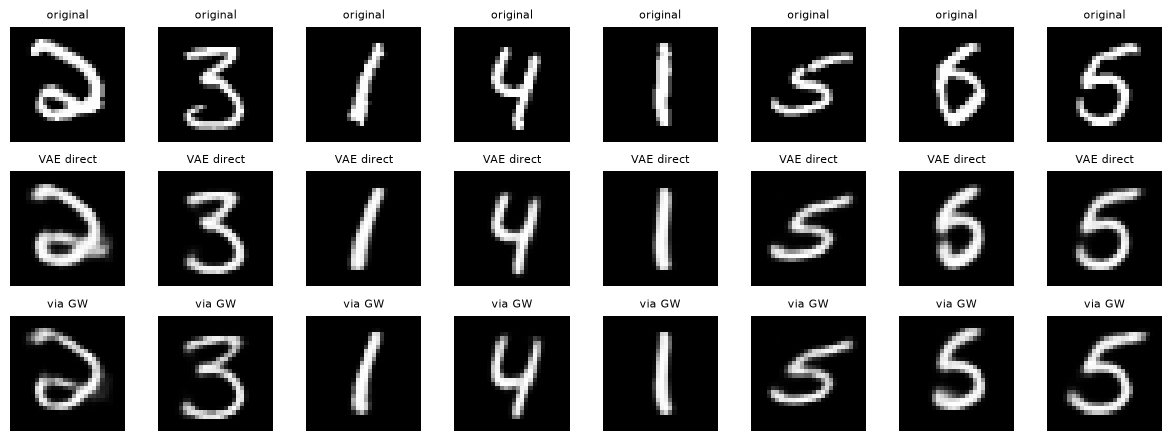

In [132]:
import matplotlib.pyplot as plt
import torch

data_loader = data_module.test_dataloader()
mnist_vae = gw.gw_mod.domain_mods.image.vae
image_encoder = gw.gw_mod.gw_encoders.image
image_decoder = gw.gw_mod.gw_decoders.image

mnist_vae.eval()
image_encoder.eval()
image_decoder.eval()

# Récupère un batch depuis le CombinedLoader
batch, batch_idx, dataloader_idx = next(iter(data_loader))

image_batch = None
for key, value in batch.items():
    if "image" in value:
        image_batch = value["image"]
        break

if image_batch is None:
    raise ValueError("Aucune clé du batch ne contient 'image'")

device = next(mnist_vae.parameters()).device
image_batch = image_batch.to(device)

with torch.no_grad():
    # 1. Image -> espace latent VAE (mu, 12D)
    mu, logvar = mnist_vae.encoder(image_batch)
    print("mu (latent VAE) shape:", mu.shape)

    # 2. Espace latent VAE -> espace global workspace
    gw_latent = image_encoder(mu)
    print("gw_latent (global workspace) shape:", gw_latent.shape)

    # 3. Espace global workspace -> espace latent VAE (retour)
    mu_reconstructed = image_decoder(gw_latent)
    print("mu_reconstructed shape:", mu_reconstructed.shape)

    # 4. Espace latent VAE -> image reconstruite
    reconstructed = mnist_vae.decoder(mu_reconstructed)
    print("reconstructed shape:", reconstructed.shape)

    # Reconstruction "directe" (sans passer par le GW) pour comparaison
    direct_reconstructed = mnist_vae.decoder(mu)

# Erreurs
mse_full_pipeline = torch.nn.functional.mse_loss(reconstructed, image_batch)
mse_direct = torch.nn.functional.mse_loss(direct_reconstructed, image_batch)
mse_latent_roundtrip = torch.nn.functional.mse_loss(mu_reconstructed, mu)

print(f"MSE pipeline complet (image -> GW -> image): {mse_full_pipeline.item():.6f}")
print(f"MSE reconstruction directe (image -> VAE seul): {mse_direct.item():.6f}")
print(f"MSE round-trip latent (mu vs mu_reconstructed): {mse_latent_roundtrip.item():.6f}")

# Visualisation : original vs reconstruction directe vs reconstruction via GW
n_show = min(8, image_batch.shape[0])
fig, axes = plt.subplots(3, n_show, figsize=(n_show * 1.5, 4.5))

for i in range(n_show):
    axes[0, i].imshow(image_batch[i, 0].cpu().numpy(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("original", fontsize=8)

    axes[1, i].imshow(direct_reconstructed[i, 0].cpu().numpy(), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("VAE direct", fontsize=8)

    axes[2, i].imshow(reconstructed[i, 0].cpu().numpy(), cmap="gray")
    axes[2, i].axis("off")
    axes[2, i].set_title("via GW", fontsize=8)

plt.tight_layout()
plt.show()

=== digit -> image ===
image_from_digit shape: torch.Size([50, 1, 28, 28])

=== image -> digit ===
digit_pred shape: torch.Size([50, 10])
Accuracy (image -> digit prédit): 94.00%


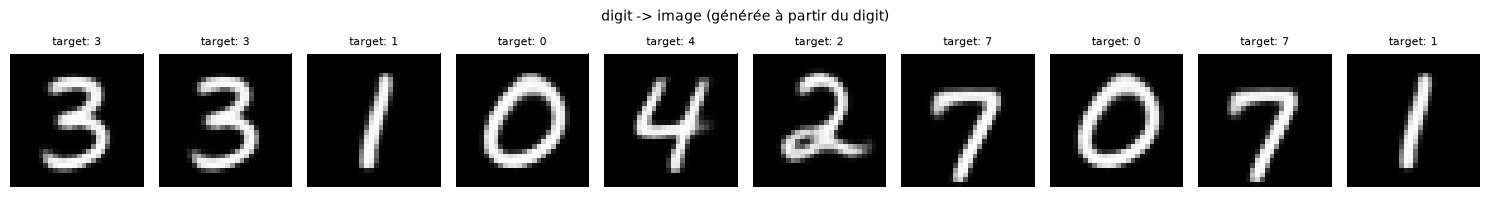

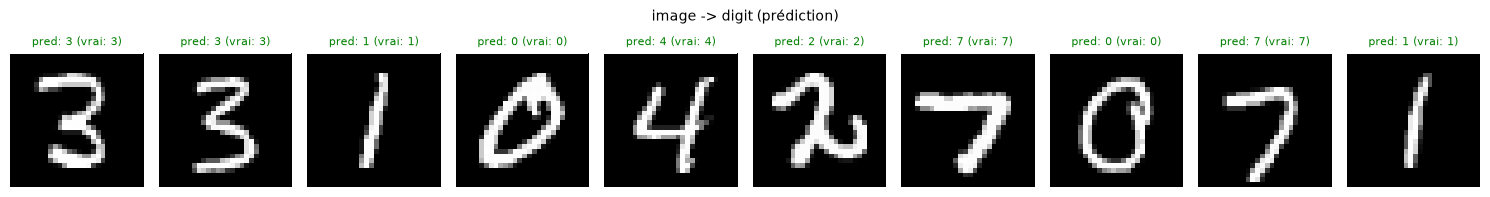

In [133]:
import matplotlib.pyplot as plt
import torch

train_loader = data_module.train_dataloader()
mnist_vae = gw.gw_mod.domain_mods.image.vae
image_encoder = gw.gw_mod.gw_encoders.image
image_decoder = gw.gw_mod.gw_decoders.image
digit_encoder = gw.gw_mod.gw_encoders.digit
digit_decoder = gw.gw_mod.gw_decoders.digit

mnist_vae.eval()
image_encoder.eval()
image_decoder.eval()
digit_encoder.eval()
digit_decoder.eval()

# Récupère un batch avec image ET digit (le domaine combiné)
batch, batch_idx, dataloader_idx = next(iter(train_loader))

image_batch, digit_batch = None, None
for key, value in batch.items():
    if "image" in value and "digit" in value:
        image_batch = value["image"]
        digit_batch = value["digit"]
        break

if image_batch is None:
    raise ValueError("Aucune clé du batch ne contient à la fois 'image' et 'digit'")

device = next(mnist_vae.parameters()).device
image_batch = image_batch.to(device)
digit_batch = digit_batch.to(device)

with torch.no_grad():
    # ---- Direction 1 : digit -> image ----
    # digit (one-hot 10D) -> espace GW
    gw_latent_from_digit = digit_encoder(digit_batch)
    # espace GW -> espace latent VAE (12D)
    mu_from_digit = image_decoder(gw_latent_from_digit)
    # espace latent VAE -> image
    image_from_digit = mnist_vae.decoder(mu_from_digit)

    # ---- Direction 2 : image -> digit ----
    # image -> espace latent VAE (12D)
    mu_from_image, _ = mnist_vae.encoder(image_batch)
    # espace latent VAE -> espace GW
    gw_latent_from_image = image_encoder(mu_from_image)
    # espace GW -> digit (one-hot 10D)
    digit_pred = digit_decoder(gw_latent_from_image)

# ---- Évaluation : digit -> image ----
true_digits = digit_batch.argmax(dim=1)
print("=== digit -> image ===")
print("image_from_digit shape:", image_from_digit.shape)

# ---- Évaluation : image -> digit ----
predicted_digits = digit_pred.argmax(dim=1)
accuracy = (predicted_digits == true_digits).float().mean()
print("\n=== image -> digit ===")
print("digit_pred shape:", digit_pred.shape)
print(f"Accuracy (image -> digit prédit): {accuracy.item():.2%}")

# ---- Visualisation : digit -> image ----
n_show = min(10, image_batch.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 1.5, 2))
fig.suptitle("digit -> image (générée à partir du digit)", fontsize=10)

for i in range(n_show):
    axes[i].imshow(image_from_digit[i, 0].cpu().numpy(), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"target: {true_digits[i].item()}", fontsize=8)

plt.tight_layout()
plt.show()

# ---- Visualisation : image -> digit ----
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 1.5, 2))
fig.suptitle("image -> digit (prédiction)", fontsize=10)

for i in range(n_show):
    color = "green" if predicted_digits[i] == true_digits[i] else "red"
    axes[i].imshow(image_batch[i, 0].cpu().numpy(), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(
        f"pred: {predicted_digits[i].item()} (vrai: {true_digits[i].item()})",
        fontsize=8,
        color=color,
    )

plt.tight_layout()
plt.show()


pixel_space: (2000, 784)
vision_domain_space: (2000, 12)
gw_space: (2000, 10)


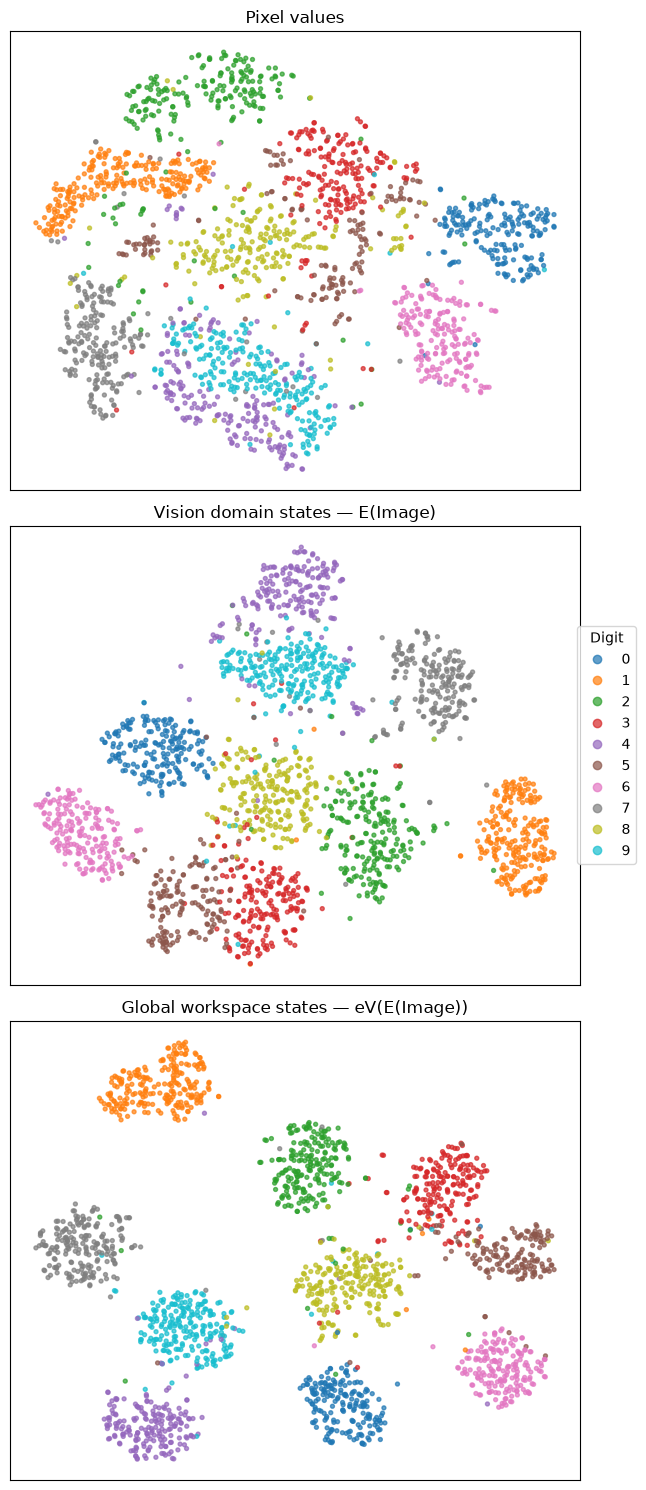

In [134]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE

mnist_vae = gw.gw_mod.domain_mods.image.vae
image_encoder = gw.gw_mod.gw_encoders.image

mnist_vae.eval()
image_encoder.eval()

# --- 1. Récupérer un échantillon suffisant du dataset (pas juste un batch) ---
N_SAMPLES = 2000  # t-SNE devient lent au-delà de quelques milliers de points

mnist_test = data_module.mnist_test  # dataset torchvision brut (image, label)
indices = np.random.choice(len(mnist_test), N_SAMPLES, replace=False)

images = torch.stack([mnist_test[i][0] for i in indices])  # (N, 1, 28, 28)
labels = np.array([mnist_test[i][1] for i in indices])     # (N,)

device = next(mnist_vae.parameters()).device
images = images.to(device)

# --- 2. Calculer les 3 représentations ---
with torch.no_grad():
    # (a) pixels bruts, aplatis
    pixel_space = images.view(images.shape[0], -1).cpu().numpy()  # (N, 784)

    # (b) états du domaine vision : sortie de l'encoder VAE (E(Image))
    mu, _ = mnist_vae.encoder(images)
    vision_domain_space = mu.cpu().numpy()  # (N, 12)

    # (c) états du global workspace : eV(E(Image))
    gw_latent = image_encoder(mu)
    gw_space = gw_latent.cpu().numpy()  # (N, gw_dim)

print("pixel_space:", pixel_space.shape)
print("vision_domain_space:", vision_domain_space.shape)
print("gw_space:", gw_space.shape)

# --- 3. t-SNE sur chacun des 3 espaces ---
def compute_tsne(X, seed=42):
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        random_state=seed,
    )
    return tsne.fit_transform(X)

tsne_pixel = compute_tsne(pixel_space)
tsne_vision = compute_tsne(vision_domain_space)
tsne_gw = compute_tsne(gw_space)

# --- 4. Visualisation : 3 panneaux empilés, colorés par digit ---
fig, axes = plt.subplots(3, 1, figsize=(6, 15))
titles = [
    "Pixel values",
    "Vision domain states — E(Image)",
    "Global workspace states — eV(E(Image))",
]
tsne_results = [tsne_pixel, tsne_vision, tsne_gw]

for ax, tsne_res, title in zip(axes, tsne_results, titles):
    scatter = ax.scatter(
        tsne_res[:, 0],
        tsne_res[:, 1],
        c=labels,
        cmap="tab10",
        s=8,
        alpha=0.7,
    )
    ax.set_title(title, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# Légende commune (une seule, à droite)
handles, _ = scatter.legend_elements()
fig.legend(
    handles,
    [str(i) for i in range(10)],
    loc="center right",
    bbox_to_anchor=(1.08, 0.5),
    title="Digit",
)

plt.tight_layout()
plt.show()

In [135]:
import torch

train_loader = data_module.train_dataloader()
mnist_vae = gw.gw_mod.domain_mods.image.vae
image_encoder = gw.gw_mod.gw_encoders.image
image_decoder = gw.gw_mod.gw_decoders.image
digit_encoder = gw.gw_mod.gw_encoders.digit
digit_decoder = gw.gw_mod.gw_decoders.digit
ope = gw.operation_module

mnist_vae.eval()
image_encoder.eval()
image_decoder.eval()
digit_encoder.eval()
digit_decoder.eval()
ope.eval()

device = next(mnist_vae.parameters()).device

# Récupère un batch avec image ET digit (le domaine combiné)
batch, batch_idx, dataloader_idx = next(iter(train_loader))

image_batch, digit_batch = None, None
for key, value in batch.items():
    if "image" in value and "digit" in value:
        image_batch = value["image"].to(device)
        digit_batch = value["digit"].to(device)
        break

if digit_batch is None:
    raise ValueError("Aucune clé du batch ne contient à la fois 'image' et 'digit'")

with torch.no_grad():
    # 1. digit one-hot -> espace GW
    gw_input = digit_encoder(digit_batch)

    # 2. Applique l'opération (-1) dans l'espace GW
    batch_size = digit_batch.shape[0]
    shift = -1
    task = torch.full(
        (batch_size, 1),
        fill_value=float(shift),
        device=device,
    )
    gw_pred = ope(gw_input, task)

    # 3. espace GW -> digit one-hot prédit
    digit_pred_logits = digit_decoder(gw_pred)
    digit_pred = digit_pred_logits.argmax(dim=1)

# Vérité terrain : digit original -1 (mod 10)
true_digits = digit_batch.argmax(dim=1)
expected_digits = (true_digits + shift) % 10

# Évaluation
accuracy = (digit_pred == expected_digits).float().mean()
print(f"Shift appliqué: {shift}")
print(f"Accuracy opération (-1): {accuracy.item():.2%}")

# Affichage détaillé de quelques exemples
n_show = min(10, batch_size)
for i in range(n_show):
    status = "✓" if digit_pred[i] == expected_digits[i] else "✗"
    print(
        f"{status} digit original: {true_digits[i].item()} "
        f"-> attendu: {expected_digits[i].item()}, "
        f"prédit: {digit_pred[i].item()}"
    )

Shift appliqué: -1
Accuracy opération (-1): 100.00%
✓ digit original: 0 -> attendu: 9, prédit: 9
✓ digit original: 4 -> attendu: 3, prédit: 3
✓ digit original: 1 -> attendu: 0, prédit: 0
✓ digit original: 6 -> attendu: 5, prédit: 5
✓ digit original: 7 -> attendu: 6, prédit: 6
✓ digit original: 2 -> attendu: 1, prédit: 1
✓ digit original: 1 -> attendu: 0, prédit: 0
✓ digit original: 6 -> attendu: 5, prédit: 5
✓ digit original: 0 -> attendu: 9, prédit: 9
✓ digit original: 9 -> attendu: 8, prédit: 8


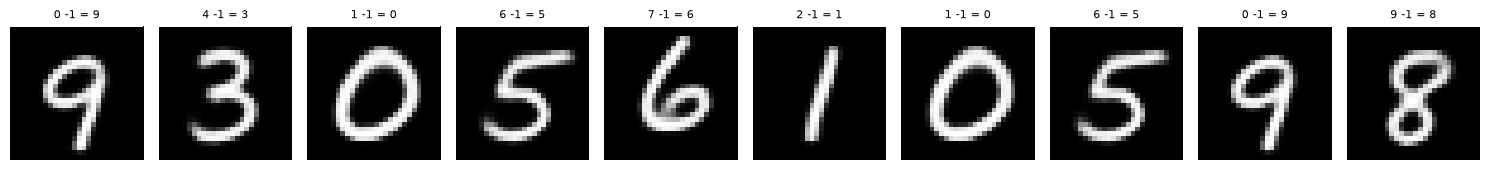

In [136]:
with torch.no_grad():
    mu_from_op = image_decoder(gw_pred)
    image_from_op = mnist_vae.decoder(mu_from_op)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, n_show, figsize=(n_show * 1.5, 2))
for i in range(n_show):
    axes[i].imshow(image_from_op[i, 0].cpu().numpy(), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"{true_digits[i].item()} -1 = {digit_pred[i].item()}", fontsize=8)
plt.tight_layout()
plt.show()

=== Répétition de +1 ===
Séquence: [1] (somme=1) -> accuracy: 100.00%
Séquence: [1, 1] (somme=2) -> accuracy: 100.00%
Séquence: [1, 1, 1] (somme=3) -> accuracy: 100.00%
Séquence: [1, 1, 1, 1] (somme=4) -> accuracy: 100.00%
Séquence: [1, 1, 1, 1, 1] (somme=5) -> accuracy: 100.00%

=== Répétition de -1 ===
Séquence: [-1] (somme=-1) -> accuracy: 100.00%
Séquence: [-1, -1] (somme=-2) -> accuracy: 100.00%
Séquence: [-1, -1, -1] (somme=-3) -> accuracy: 100.00%
Séquence: [-1, -1, -1, -1] (somme=-4) -> accuracy: 100.00%
Séquence: [-1, -1, -1, -1, -1] (somme=-5) -> accuracy: 100.00%

=== Combinaisons aléatoires ===
Séquence: [1, -1, 1, 1, 1] (somme=3) -> accuracy: 100.00%
Séquence: [1, 1, -1, -1] (somme=0) -> accuracy: 100.00%
Séquence: [-1, -1, 1, -1] (somme=-2) -> accuracy: 100.00%
Séquence: [-1, -1, 1, 1] (somme=0) -> accuracy: 100.00%
Séquence: [1, 1] (somme=2) -> accuracy: 100.00%

=== Accuracy moyenne par longueur de séquence (+1 répété) ===
n=1: 100.00%
n=2: 100.00%
n=3: 100.00%
n=4: 100

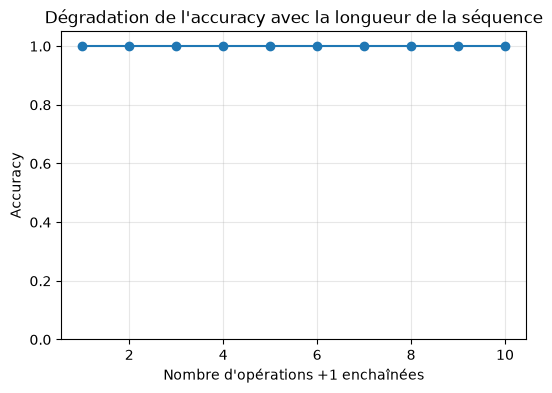

In [137]:
import torch
import matplotlib.pyplot as plt

train_loader = data_module.train_dataloader()
mnist_vae = gw.gw_mod.domain_mods.image.vae
image_decoder = gw.gw_mod.gw_decoders.image
digit_encoder = gw.gw_mod.gw_encoders.digit
digit_decoder = gw.gw_mod.gw_decoders.digit
ope = gw.operation_module

mnist_vae.eval()
image_decoder.eval()
digit_encoder.eval()
digit_decoder.eval()
ope.eval()

device = next(mnist_vae.parameters()).device


def apply_operation_sequence(digit_batch: torch.Tensor, shifts: list[int]) -> torch.Tensor:
    """
    Applique une séquence de shifts successifs dans l'espace GW.
    Retourne l'état GW final après toutes les opérations.
    """
    batch_size = digit_batch.shape[0]

    with torch.no_grad():
        gw_state = digit_encoder(digit_batch)

        for shift in shifts:
            task = torch.full(
                (batch_size, 1),
                fill_value=float(shift),
                device=device,
            )
            gw_state = ope(gw_state, task)

    return gw_state


def evaluate_sequence(digit_batch: torch.Tensor, shifts: list[int], verbose: bool = True):
    """Évalue l'accuracy après une séquence d'opérations donnée."""
    true_digits = digit_batch.argmax(dim=1)
    expected_digits = (true_digits + sum(shifts)) % 10

    gw_final = apply_operation_sequence(digit_batch, shifts)

    with torch.no_grad():
        digit_pred_logits = digit_decoder(gw_final)
        digit_pred = digit_pred_logits.argmax(dim=1)

    accuracy = (digit_pred == expected_digits).float().mean()

    if verbose:
        print(f"Séquence: {shifts} (somme={sum(shifts)}) -> accuracy: {accuracy.item():.2%}")

    return accuracy.item(), digit_pred, expected_digits, gw_final


# --- Récupère un batch ---
batch, batch_idx, dataloader_idx = next(iter(train_loader))

digit_batch = None
for key, value in batch.items():
    if "image" in value and "digit" in value:
        digit_batch = value["digit"].to(device)
        break

if digit_batch is None:
    raise ValueError("Aucune clé du batch ne contient 'digit'")

# --- Test 1 : répéter +1 plusieurs fois ---
print("=== Répétition de +1 ===")
for n in range(1, 6):
    evaluate_sequence(digit_batch, [1] * n)

print("\n=== Répétition de -1 ===")
for n in range(1, 6):
    evaluate_sequence(digit_batch, [-1] * n)

# --- Test 2 : combinaisons aléatoires ---
print("\n=== Combinaisons aléatoires ===")
import random

random.seed(0)
for _ in range(5):
    n_ops = random.randint(2, 5)
    shifts = [random.choice([-1, 1]) for _ in range(n_ops)]
    evaluate_sequence(digit_batch, shifts)

# --- Test 3 : accuracy moyenne par longueur de séquence (plus robuste) ---
print("\n=== Accuracy moyenne par longueur de séquence (+1 répété) ===")
max_len = 10
accuracies = []
for n in range(1, max_len + 1):
    acc, _, _, _ = evaluate_sequence(digit_batch, [1] * n, verbose=False)
    accuracies.append(acc)
    print(f"n={n}: {acc:.2%}")

plt.figure(figsize=(6, 4))
plt.plot(range(1, max_len + 1), accuracies, marker="o")
plt.xlabel("Nombre d'opérations +1 enchaînées")
plt.ylabel("Accuracy")
plt.title("Dégradation de l'accuracy avec la longueur de la séquence")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

gw_states_per_digit shape: (10, 10)


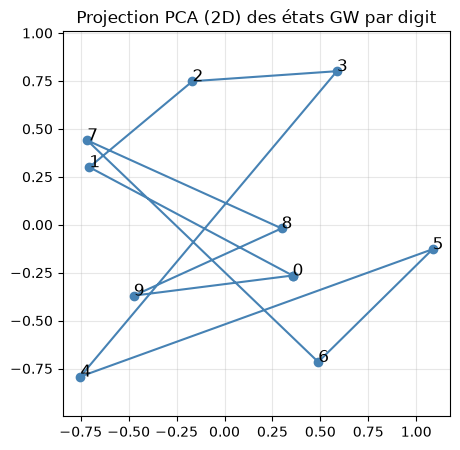

Variance expliquée par les 2 premières composantes: 56.77%
R² global (cos/sin -> espace GW complet): 0.1652


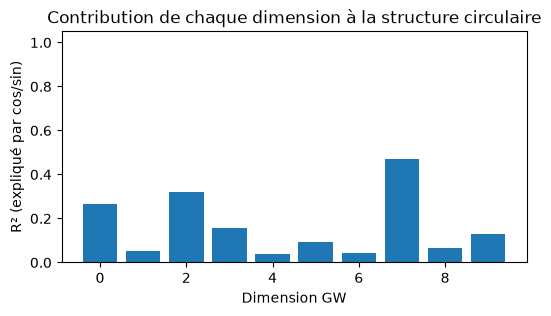

Écarts angulaires mesurés entre digits consécutifs (rad): [0.14777875 1.35849947 0.33065462 0.52389063 0.05315462 1.00287707
 0.85141152 0.80025339 0.14850783 1.0661574 ]
Écart théorique attendu (2π/10): 0.6283
Std des écarts (plus bas = plus régulier): 0.4285


In [138]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

digit_encoder = gw.gw_mod.gw_encoders.digit
digit_encoder.eval()
device = next(digit_encoder.parameters()).device

# --- 1. Calculer l'état GW moyen pour chaque digit (0 à 9) ---
NUM_DIGITS = 10
gw_states_per_digit = []

with torch.no_grad():
    for d in range(NUM_DIGITS):
        one_hot = torch.zeros(1, NUM_DIGITS, device=device)
        one_hot[0, d] = 1.0
        gw_state = digit_encoder(one_hot)  # (1, gw_size)
        gw_states_per_digit.append(gw_state.squeeze(0).cpu().numpy())

gw_states_per_digit = np.stack(gw_states_per_digit)  # (10, gw_size)
print("gw_states_per_digit shape:", gw_states_per_digit.shape)

# --- 2. PCA à 2D pour visualiser ---
pca = PCA(n_components=2)
gw_2d = pca.fit_transform(gw_states_per_digit)

plt.figure(figsize=(5, 5))
plt.plot(
    np.append(gw_2d[:, 0], gw_2d[0, 0]),
    np.append(gw_2d[:, 1], gw_2d[0, 1]),
    "-o",
    color="steelblue",
)
for d in range(NUM_DIGITS):
    plt.annotate(str(d), (gw_2d[d, 0], gw_2d[d, 1]), fontsize=12)
plt.title("Projection PCA (2D) des états GW par digit")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Variance expliquée par les 2 premières composantes: {pca.explained_variance_ratio_.sum():.2%}")

# --- 3. Test quantitatif : régression sur cos/sin (mesure de circularité) ---
angles = 2 * np.pi * np.arange(NUM_DIGITS) / NUM_DIGITS
features = np.stack([np.cos(angles), np.sin(angles)], axis=1)  # (10, 2)

reg = LinearRegression()
reg.fit(features, gw_states_per_digit)  # prédit les 10 (ou gw_size) dims depuis cos/sin
predictions = reg.predict(features)

ss_res = ((gw_states_per_digit - predictions) ** 2).sum()
ss_tot = ((gw_states_per_digit - gw_states_per_digit.mean(axis=0)) ** 2).sum()
r2 = 1 - ss_res / ss_tot
print(f"R² global (cos/sin -> espace GW complet): {r2:.4f}")

# R² par dimension individuelle (pour voir quelles dims portent la structure circulaire)
r2_per_dim = []
for i in range(gw_states_per_digit.shape[1]):
    ss_res_i = ((gw_states_per_digit[:, i] - predictions[:, i]) ** 2).sum()
    ss_tot_i = ((gw_states_per_digit[:, i] - gw_states_per_digit[:, i].mean()) ** 2).sum()
    r2_i = 1 - ss_res_i / ss_tot_i if ss_tot_i > 1e-8 else 0.0
    r2_per_dim.append(r2_i)

plt.figure(figsize=(6, 3))
plt.bar(range(len(r2_per_dim)), r2_per_dim)
plt.xlabel("Dimension GW")
plt.ylabel("R² (expliqué par cos/sin)")
plt.title("Contribution de chaque dimension à la structure circulaire")
plt.ylim(0, 1.05)
plt.show()

# --- 4. Test d'espacement angulaire égal (les digits doivent être équidistants sur le cercle) ---
center = gw_2d.mean(axis=0)
centered = gw_2d - center
measured_angles = np.arctan2(centered[:, 1], centered[:, 0])
measured_angles = np.unwrap(np.sort(measured_angles))  # trie et déroule

angle_diffs = np.diff(np.append(measured_angles, measured_angles[0] + 2 * np.pi))
print("Écarts angulaires mesurés entre digits consécutifs (rad):", angle_diffs)
print(f"Écart théorique attendu (2π/10): {2 * np.pi / NUM_DIGITS:.4f}")
print(f"Std des écarts (plus bas = plus régulier): {angle_diffs.std():.4f}")

In [139]:
activations = {}
def hook(module, input, output):
    activations["hidden"] = output.detach()

hook_handle = ope.transfo[1].register_forward_hook(hook)  # après le ReLU

with torch.no_grad():
    for d in range(NUM_DIGITS):
        one_hot = torch.zeros(1, NUM_DIGITS, device=device)
        one_hot[0, d] = 1.0
        gw_state = digit_encoder(one_hot)
        task = torch.full((1, 1), fill_value=1.0, device=device)
        _ = ope(gw_state, task)
        # activations["hidden"] contient la sortie de la couche cachée pour ce digit

hook_handle.remove()

hidden_states_per_digit shape: (10, 128)
Variance expliquée (PCA, 2 composantes): 60.08%


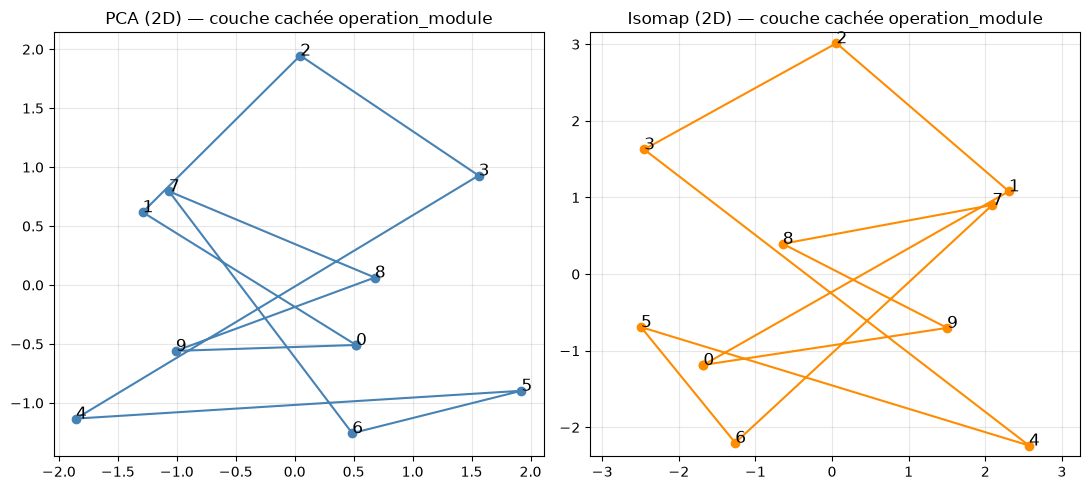

R² global (cos/sin -> couche cachée complète): 0.1585

Top 10 dimensions les plus expliquées par cos/sin:
  dim 59: R² = 0.5441
  dim 126: R² = 0.4752
  dim 3: R² = 0.4049
  dim 73: R² = 0.3951
  dim 64: R² = 0.3774
  dim 110: R² = 0.3743
  dim 18: R² = 0.3656
  dim 94: R² = 0.3398
  dim 33: R² = 0.3394
  dim 93: R² = 0.3295


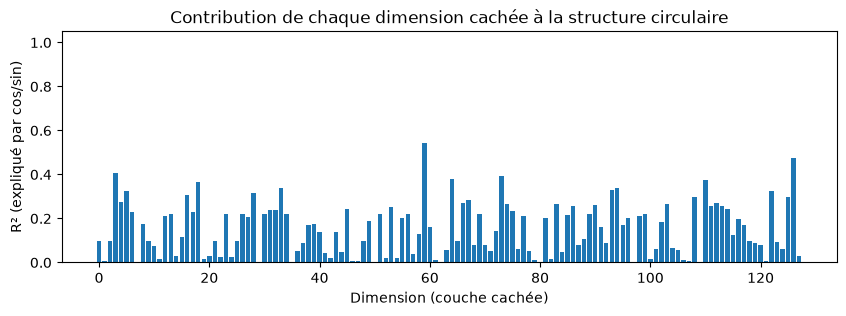


Ordre des digits sur le cercle (PCA): [9, 4, 6, 0, 5, 8, 3, 2, 7, 1]
Ordre cyclique cohérent (rotation/réflexion de 0..9): False
Std des écarts angulaires (PCA): 0.4054 (théorique idéal: 0)

Ordre des digits sur le cercle (Isomap): [5, 0, 6, 4, 9, 7, 1, 2, 3, 8]
Ordre cyclique cohérent (rotation/réflexion de 0..9): False
Std des écarts angulaires (Isomap): 0.4438 (théorique idéal: 0)


False

In [140]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.linear_model import LinearRegression

digit_encoder = gw.gw_mod.gw_encoders.digit
ope = gw.operation_module

digit_encoder.eval()
ope.eval()
device = next(digit_encoder.parameters()).device

NUM_DIGITS = 10
SHIFT = 1  # tâche utilisée pour capturer les activations (arbitraire, teste juste la géométrie)


# --- 1. Capturer les activations de la couche cachée via un hook ---
activations = {}

def hook_fn(module, input, output):
    activations["hidden"] = output.detach()

# ope.transfo = Sequential(Linear, ReLU, Linear)
# on veut la sortie du ReLU (index 1), donc la couche cachée post-activation
hook_handle = ope.transfo[1].register_forward_hook(hook_fn)

hidden_states_per_digit = []

with torch.no_grad():
    for d in range(NUM_DIGITS):
        one_hot = torch.zeros(1, NUM_DIGITS, device=device)
        one_hot[0, d] = 1.0

        gw_state = digit_encoder(one_hot)
        task = torch.full((1, 1), fill_value=float(SHIFT), device=device)

        _ = ope(gw_state, task)  # déclenche le hook
        hidden_states_per_digit.append(activations["hidden"].squeeze(0).cpu().numpy())

hook_handle.remove()

hidden_states_per_digit = np.stack(hidden_states_per_digit)  # (10, hidden_size)
print("hidden_states_per_digit shape:", hidden_states_per_digit.shape)


# --- 2. PCA à 2D ---
pca = PCA(n_components=2)
hidden_2d_pca = pca.fit_transform(hidden_states_per_digit)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].plot(
    np.append(hidden_2d_pca[:, 0], hidden_2d_pca[0, 0]),
    np.append(hidden_2d_pca[:, 1], hidden_2d_pca[0, 1]),
    "-o",
    color="steelblue",
)
for d in range(NUM_DIGITS):
    axes[0].annotate(str(d), (hidden_2d_pca[d, 0], hidden_2d_pca[d, 1]), fontsize=12)
axes[0].set_title("PCA (2D) — couche cachée operation_module")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.3)

print(f"Variance expliquée (PCA, 2 composantes): {pca.explained_variance_ratio_.sum():.2%}")


# --- 3. Isomap à 2D (capture les structures non-linéaires) ---
isomap = Isomap(n_neighbors=4, n_components=2)
hidden_2d_isomap = isomap.fit_transform(hidden_states_per_digit)

axes[1].plot(
    np.append(hidden_2d_isomap[:, 0], hidden_2d_isomap[0, 0]),
    np.append(hidden_2d_isomap[:, 1], hidden_2d_isomap[0, 1]),
    "-o",
    color="darkorange",
)
for d in range(NUM_DIGITS):
    axes[1].annotate(str(d), (hidden_2d_isomap[d, 0], hidden_2d_isomap[d, 1]), fontsize=12)
axes[1].set_title("Isomap (2D) — couche cachée operation_module")
axes[1].axis("equal")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# --- 4. Test quantitatif : régression sur cos/sin ---
angles = 2 * np.pi * np.arange(NUM_DIGITS) / NUM_DIGITS
features = np.stack([np.cos(angles), np.sin(angles)], axis=1)  # (10, 2)

reg = LinearRegression()
reg.fit(features, hidden_states_per_digit)
predictions = reg.predict(features)

ss_res = ((hidden_states_per_digit - predictions) ** 2).sum()
ss_tot = ((hidden_states_per_digit - hidden_states_per_digit.mean(axis=0)) ** 2).sum()
r2 = 1 - ss_res / ss_tot
print(f"R² global (cos/sin -> couche cachée complète): {r2:.4f}")

# R² par dimension individuelle
r2_per_dim = []
for i in range(hidden_states_per_digit.shape[1]):
    ss_res_i = ((hidden_states_per_digit[:, i] - predictions[:, i]) ** 2).sum()
    ss_tot_i = ((hidden_states_per_digit[:, i] - hidden_states_per_digit[:, i].mean()) ** 2).sum()
    r2_i = 1 - ss_res_i / ss_tot_i if ss_tot_i > 1e-8 else 0.0
    r2_per_dim.append(r2_i)

top_dims = np.argsort(r2_per_dim)[::-1][:10]
print("\nTop 10 dimensions les plus expliquées par cos/sin:")
for dim in top_dims:
    print(f"  dim {dim}: R² = {r2_per_dim[dim]:.4f}")

plt.figure(figsize=(10, 3))
plt.bar(range(len(r2_per_dim)), r2_per_dim)
plt.xlabel("Dimension (couche cachée)")
plt.ylabel("R² (expliqué par cos/sin)")
plt.title("Contribution de chaque dimension cachée à la structure circulaire")
plt.ylim(0, 1.05)
plt.show()


# --- 5. Ordre topologique (peu importe la régularité géométrique) ---
def check_cyclic_order(points_2d, label=""):
    center = points_2d.mean(axis=0)
    centered = points_2d - center
    measured_angles = np.arctan2(centered[:, 1], centered[:, 0])

    order = np.argsort(measured_angles)
    print(f"\nOrdre des digits sur le cercle ({label}): {order.tolist()}")

    # Vérifie si l'ordre est une rotation/réflexion de [0..9]
    order_list = order.tolist()
    expected_fwd = list(range(NUM_DIGITS))
    expected_bwd = list(range(NUM_DIGITS - 1, -1, -1))

    def is_rotation(seq, ref):
        seq2 = seq + seq
        for i in range(len(ref)):
            if seq2[i:i + len(ref)] == ref:
                return True
        return False

    is_cyclic = is_rotation(order_list, expected_fwd) or is_rotation(order_list, expected_bwd)
    print(f"Ordre cyclique cohérent (rotation/réflexion de 0..9): {is_cyclic}")

    # Régularité des écarts angulaires
    sorted_angles = np.sort(measured_angles)
    angle_diffs = np.diff(np.append(sorted_angles, sorted_angles[0] + 2 * np.pi))
    print(f"Std des écarts angulaires ({label}): {angle_diffs.std():.4f} (théorique idéal: 0)")

    return is_cyclic


check_cyclic_order(hidden_2d_pca, label="PCA")
check_cyclic_order(hidden_2d_isomap, label="Isomap")